# 📰 Fake News Detection with LSTM
### Neural Networks Project

This notebook builds and compares two LSTM models (Adam vs SGD) for binary fake-news classification.

**Pipeline overview:**
1. Load & label data  
2. EDA & Visualisation  
3. Text pre-processing  
4. Tokenisation & padding  
5. Model architecture  
6. Train & compare optimisers  
7. Evaluation & results


## 1. Imports

In [10]:
import os
import re
import string
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

print(f"TensorFlow version: {tf.__version__}")
print(f"Pandas version:     {pd.__version__}")


TensorFlow version: 2.21.0
Pandas version:     3.0.1


## 2. Load & Label Data

We load the two separate CSVs, assign binary labels, merge them, and shuffle the result.

| Label | Meaning |
|-------|---------|
| `0`   | Fake news |
| `1`   | Real news |


In [11]:
DATA_DIR = r"C:\Users\LOQ\Documents\STUDYING\3rd\Semester 2\Neural Network\Project"  

df_fake = pd.read_csv(os.path.join(DATA_DIR, "Fake.csv"))
df_true = pd.read_csv(os.path.join(DATA_DIR, "True.csv"))

df_fake['label'] = 0   # Fake
df_true['label'] = 1   # Real

df = pd.concat([df_fake, df_true], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total records : {len(df):,}")
print(f"Fake news     : {(df.label==0).sum():,}")
print(f"Real news     : {(df.label==1).sum():,}")
df.head()


Total records : 44,898
Fake news     : 23,481
Real news     : 21,417


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


## 3. Exploratory Data Analysis (EDA)

In [12]:
# ── 3.1  Basic info ───────────────────────────────────────
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())


Shape: (44898, 5)

Missing values:
title      0
text       0
subject    0
date       0
label      0
dtype: int64

Duplicates: 209


In [13]:
# Drop exact duplicates
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"After dedup: {len(df):,} rows")


After dedup: 44,689 rows


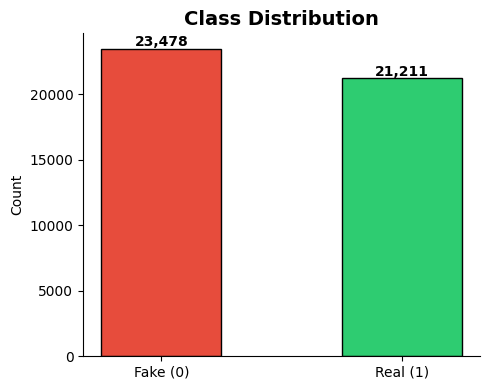

In [14]:
# ── 3.2  Class distribution ───────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
counts = df['label'].value_counts()
bars = ax.bar(['Fake (0)', 'Real (1)'], counts.values,
              color=['#e74c3c', '#2ecc71'], edgecolor='black', width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', fontweight='bold')
ax.set_title('Class Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
sns.despine()
plt.tight_layout()
plt.show()


In [15]:
# ── 3.3  Combine title + text, compute article length ─────
df['combined'] = df['title'].fillna('') + ' ' + df['text'].fillna('')
df['length'] = df['combined'].apply(len)

print(df['length'].describe().round(1))


count    44689.0
mean      2548.3
std       2174.6
min         31.0
25%       1314.0
50%       2268.0
75%       3186.0
max      51893.0
Name: length, dtype: float64


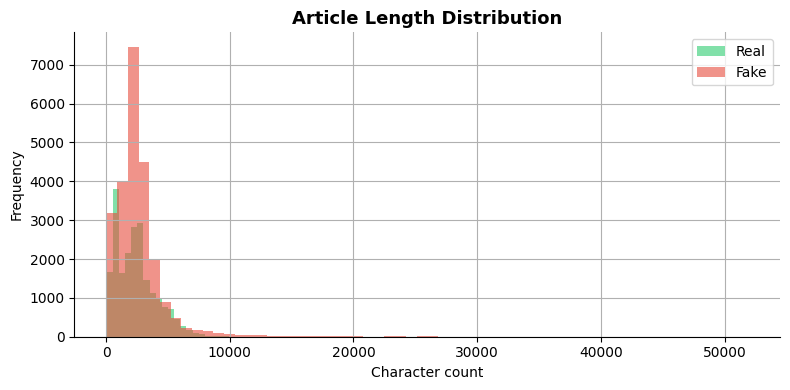

In [16]:
# ── 3.4  Length distribution by class ────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
df[df.label == 1]['length'].hist(ax=ax, bins=60, alpha=0.6,
                                  color='#2ecc71', label='Real')
df[df.label == 0]['length'].hist(ax=ax, bins=60, alpha=0.6,
                                  color='#e74c3c', label='Fake')
ax.set_title('Article Length Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Character count')
ax.set_ylabel('Frequency')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()


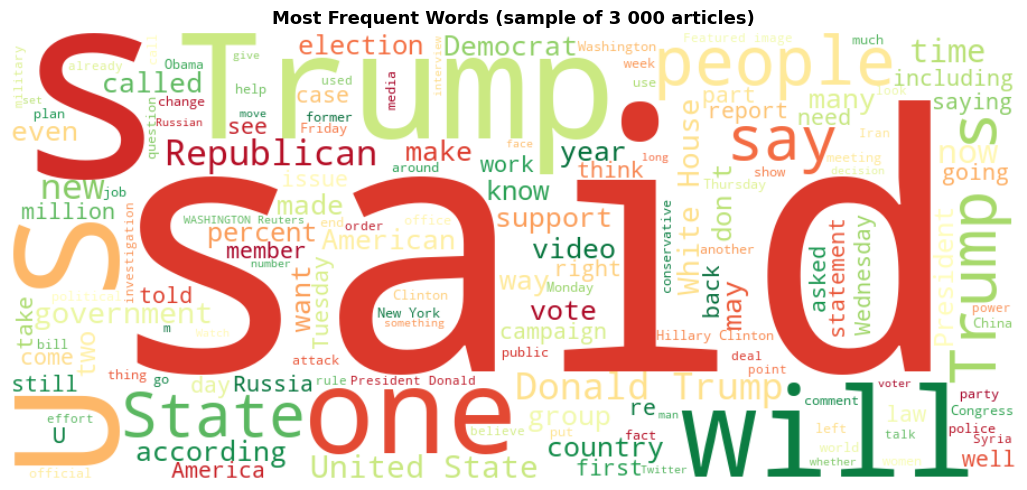

In [17]:
# ── 3.5  Word cloud (all articles) ───────────────────────
text_sample = ' '.join(df['combined'].sample(3000, random_state=42))
wc = WordCloud(width=900, height=400, background_color='white',
               colormap='RdYlGn', max_words=150).generate(text_sample)

plt.figure(figsize=(12, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words (sample of 3 000 articles)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


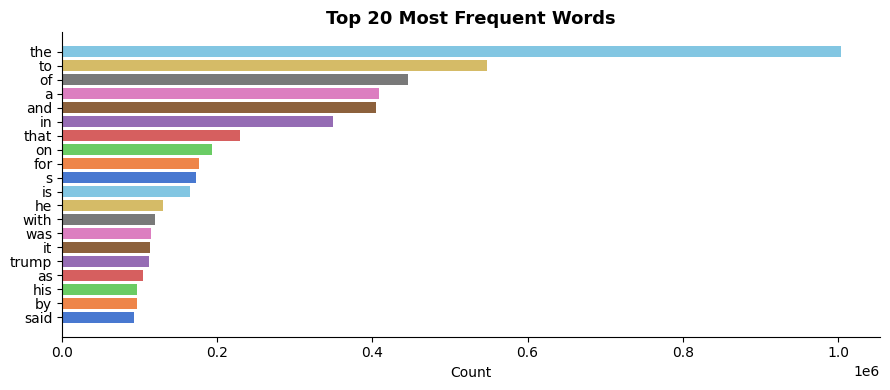

In [18]:
# ── 3.6  Top 20 words ────────────────────────────────────
all_words = ' '.join(df['combined']).lower().split()
top20 = Counter(all_words).most_common(20)
words, freqs = zip(*top20)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(list(reversed(words)), list(reversed(freqs)),
        color=sns.color_palette('muted', 20))
ax.set_title('Top 20 Most Frequent Words', fontsize=13, fontweight='bold')
ax.set_xlabel('Count')
sns.despine()
plt.tight_layout()
plt.show()


## 4. Text Pre-processing

We apply a cleaning function that:
- Lower-cases text  
- Removes URLs, HTML tags, square-bracket spans  
- Strips punctuation  
- Collapses whitespace / newlines


In [19]:
def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'\[.*?\]', '', text)                    # [tag] spans
    text = re.sub(r'https?://\S+|www\.\S+', '', text)    # URLs
    text = re.sub(r'<.*?>', '', text)                        # HTML tags
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)  # punctuation
    text = re.sub(r'\s+', ' ', text).strip()                # whitespace
    return text

df['clean_text'] = df['combined'].apply(clean_text)
print("Sample cleaned text:")
print(df['clean_text'].iloc[0][:300])


Sample cleaned text:
ben stein calls out 9th circuit court committed a ‘coup d’état’ against the constitution 21st century wire says ben stein reputable professor from pepperdine university also of some hollywood fame appearing in tv shows and films such as ferris bueller s day off made some provocative statements on ju


## 5. Tokenisation, Padding & Train/Test Split

| Hyperparameter | Value | Reason |
|---|---|---|
| `MAX_VOCAB` | 10 000 | Covers the most informative vocabulary |
| `MAX_LEN`   | 300   | Captures most article content without excessive padding |
| Test size   | 20 %  | Standard holdout proportion |


In [20]:
MAX_VOCAB = 10_000
MAX_LEN   = 300

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean_text'])

X_seq     = tokenizer.texts_to_sequences(df['clean_text'])
X_padded  = pad_sequences(X_seq, maxlen=MAX_LEN, padding='post', truncating='post')
y         = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_padded, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape}")
print(f"Test set     : {X_test.shape}")
print(f"Vocab size   : {len(tokenizer.word_index):,} unique tokens (capped at {MAX_VOCAB:,})")


Training set : (35751, 300)
Test set     : (8938, 300)
Vocab size   : 248,340 unique tokens (capped at 10,000)


## 6. LSTM Model Architecture

We use a **Bidirectional LSTM** so the model reads each article both forwards and backwards, giving it richer context.

```
Input → Embedding(10 000, 100) → BiLSTM(64) → Dense(32, relu) → Dropout(0.5) → Dense(1, sigmoid)
```


In [21]:
def build_model(optimizer: str) -> Sequential:
    model = Sequential([
        Embedding(input_dim=MAX_VOCAB, output_dim=100, input_length=MAX_LEN),
        Bidirectional(LSTM(64)),
        Dense(32, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')   # binary output
    ])
    model.compile(optimizer=optimizer,
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Print architecture once
build_model('adam').summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 7. Training – Adam vs SGD

We train identical models with two different optimisers and use **EarlyStopping** to halt training automatically once validation loss stops improving (patience = 2 epochs).


In [ ]:
EPOCHS     = 10          # EarlyStopping will likely stop this early
BATCH_SIZE = 128

early_stop = EarlyStopping(monitor='val_loss', patience=2,
                           restore_best_weights=True, verbose=1)

# ── Adam ──────────────────────────────────────────────────
print("=" * 50)
print("Training Model 1  —  Optimizer: Adam")
print("=" * 50)
model_adam = build_model('adam')
history_adam = model_adam.fit(
    X_train, y_train,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=[early_stop], verbose=1
)


Training Model 1  —  Optimizer: Adam
Epoch 1/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 174s 605ms/step - accuracy: 0.9693 - loss: 0.0718 - val_accuracy: 0.9984 - val_loss: 0.0094
Epoch 2/10


In [ ]:
# ── SGD ───────────────────────────────────────────────────
print("=" * 50)
print("Training Model 2  —  Optimizer: SGD")
print("=" * 50)
model_sgd = build_model('sgd')
history_sgd = model_sgd.fit(
    X_train, y_train,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=[early_stop], verbose=1
)


## 8. Learning Curves

In [ ]:
def plot_history(histories: dict, metric: str):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    colors = {'Adam': '#3498db', 'SGD': '#e67e22'}

    for i, (name, h) in enumerate(histories.items()):
        ax = axes[i]
        epochs = range(1, len(h.history[metric]) + 1)
        ax.plot(epochs, h.history[metric],
                color=colors[name], lw=2, label=f'Train {metric}')
        ax.plot(epochs, h.history[f'val_{metric}'],
                color=colors[name], lw=2, linestyle='--',
                label=f'Val {metric}')
        ax.set_title(f'{name} — {metric.capitalize()}', fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric.capitalize())
        ax.legend()
        sns.despine(ax=ax)

    plt.suptitle(f'Training vs Validation {metric.capitalize()}',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

histories = {'Adam': history_adam, 'SGD': history_sgd}
plot_history(histories, 'accuracy')
plot_history(histories, 'loss')


## 9. Evaluation & Results

In [ ]:
def evaluate_model(model, name: str):
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    y_pred = (model.predict(X_test, verbose=0) > 0.5).astype(int).flatten()

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Test accuracy : {acc:.4f}")
    print(f"  Test loss     : {loss:.4f}")
    print("\nClassification report:")
    print(classification_report(y_test, y_pred,
                                target_names=['Fake', 'Real']))

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(4, 3))
    disp = ConfusionMatrixDisplay(cm, display_labels=['Fake', 'Real'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name} — Confusion Matrix', fontweight='bold')
    plt.tight_layout()
    plt.show()

evaluate_model(model_adam, 'Adam')
evaluate_model(model_sgd,  'SGD')


## 10. Side-by-Side Comparison

In [ ]:
def final_metrics(model, history) -> dict:
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    return {
        'Test Accuracy'  : round(acc, 4),
        'Test Loss'      : round(loss, 4),
        'Epochs Trained' : len(history.history['loss']),
        'Best Val Acc'   : round(max(history.history['val_accuracy']), 4),
    }

comparison = pd.DataFrame({
    'Adam': final_metrics(model_adam, history_adam),
    'SGD' : final_metrics(model_sgd,  history_sgd),
})
print(comparison.to_string())
comparison


## 11. Conclusion

| Aspect | Observation |
|--------|-------------|
| **Adam** | Converges faster, typically reaches higher accuracy in fewer epochs |
| **SGD**  | Slower convergence; may need a learning-rate schedule to match Adam |
| **Architecture** | Bidirectional LSTM captures forward + backward context |
| **Regularisation** | Dropout (0.5) + EarlyStopping reduce overfitting |

**Key takeaway:** Adam is the better default for NLP tasks like this one. SGD can match it with careful tuning (momentum, learning-rate decay) but requires more epochs.
